# Multi-task π₀ SFT: acquisition, retention, and held-out transfer

This notebook accompanies the controlled 1/2/3-task experiment. All runs start independently from official π₀ base weights, use LoRA rank/alpha 32, batch 8, seed 0, and 3,001 optimizer updates. **H1 and H2 are excluded from every SFT corpus.** D1 and D2 scores count as transfer only for variants that did not train on them.

The default mode reads committed experiment evidence and shows its recorded rollouts. Switch `LIVE_EVALUATION` in the single configuration cell to run a compatible checkpoint again. A GPU and the pinned OpenPI/LIBERO environment are required for live inference. Reports/figures can be read on CPU.

Primary data sizes are 50/100/150 demonstrations. Task diversity is therefore confounded with total unique data and corpus-specific normalization. One training seed does not measure training-seed variance.

**Publication cutoff:** Remaining intermediate evaluations were stopped at the user’s request. All final N=50 results are complete. The trajectory displays only completed N=50 cells; missing points are not zeroes. Partial interrupted rows are preserved separately.

## 1. Configure once
Change checkpoint, task, episode count, seeds, and video count here. Paths are explicit; new rollouts receive a new output directory.

In [1]:
from pathlib import Path
import os, sys
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/maniskill_myws").exists())
EXPERIMENT_ROOT = Path("/workspace/multitask-sft")
VARIANT = "C"                 # A/B/C, or "external" for another compatible checkpoint
UPDATES = 3001
CHECKPOINT = EXPERIMENT_ROOT / VARIANT / "checkpoints/pi0_libero_seen_lora32/EXP-001" / str(UPDATES)
TASK = "H1"                   # D0, D1, D2, H1, H2
N_EPISODES = 50
SEED_START = 10000
SEED_LIST = None               # e.g. [10002, 10005]; overrides N_EPISODES
VIDEOS_PER_OUTCOME = 2
LIVE_EVALUATION = False
ALLOW_INCOMPLETE_TRAJECTORY = True  # User-requested cutoff; final N50 cells still mandatory
EVIDENCE = REPO / "docs/multitask_sft/evidence/eval"
LIBERO_ROOT = Path("/workspace/LIBERO")
NORMALIZATION = None           # checkpoint's own statistics by default
SEEN_TASKS = None              # external mode only: None = unknown; e.g. ("D0", "H1")


## 2. Load reusable helpers
Install the pinned environment with `bash scripts/pld/setup_libero.sh`. Select its Python kernel. Core evaluation lives in repository modules; the notebook supplies configuration and presentation.

In [2]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, Video, Image, Markdown
sys.path[:0] = [str(REPO / "src"), str(LIBERO_ROOT)]
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
from maniskill_myws.pld.multitask_protocol import TASKS, TRAIN_SETS, prompt, summarize, paired_change
from maniskill_myws.pld.multitask_eval import EvalConfig, EvaluationSession, save_video
from maniskill_myws.pld.multitask_report import read_results, analysis, LABELS
seeds = tuple(SEED_LIST) if SEED_LIST is not None else tuple(range(SEED_START, SEED_START + N_EPISODES))
config = EvalConfig(str(CHECKPOINT), VARIANT, TASK, seeds, VIDEOS_PER_OUTCOME, NORMALIZATION, seen_tasks=SEEN_TASKS)
if VARIANT == "external" and not LIVE_EVALUATION:
    raise ValueError("External checkpoints require LIVE_EVALUATION=True; cached evidence covers A/B/C")


## 3. Available trained checkpoints
Directory names count completed optimizer updates. Update 0 is the saved LoRA initialization, including the pinned implementation’s small random functional LoRA perturbation.

In [3]:
checkpoint_rows = []
for variant in TRAIN_SETS:
    for update in (0, 500, 1000, 2000, 3001):
        path = EXPERIMENT_ROOT / variant / "checkpoints/pi0_libero_seen_lora32/EXP-001" / str(update)
        checkpoint_rows.append({"Variant": variant, "Train set": LABELS[variant], "Updates": update, "Available locally": path.exists(), "Checkpoint": str(path)})
display(pd.DataFrame(checkpoint_rows))


,Variant,Train set,Updates,Available locally,Checkpoint
0,A,D0,0,True,/workspace/multitask-sft/A/checkpoints/pi0_lib...
1,A,D0,500,True,/workspace/multitask-sft/A/checkpoints/pi0_lib...
2,A,D0,1000,True,/workspace/multitask-sft/A/checkpoints/pi0_lib...
3,A,D0,2000,True,/workspace/multitask-sft/A/checkpoints/pi0_lib...
4,A,D0,3001,True,/workspace/multitask-sft/A/checkpoints/pi0_lib...
5,B,D0 + D1,0,True,/workspace/multitask-sft/B/checkpoints/pi0_lib...
6,B,D0 + D1,500,True,/workspace/multitask-sft/B/checkpoints/pi0_lib...
7,B,D0 + D1,1000,True,/workspace/multitask-sft/B/checkpoints/pi0_lib...
8,B,D0 + D1,2000,True,/workspace/multitask-sft/B/checkpoints/pi0_lib...
9,B,D0 + D1,3001,True,/workspace/multitask-sft/B/checkpoints/pi0_lib...


## 4. Evaluation tasks and seen/held-out status

In [4]:
display(pd.DataFrame([{"Task": key, "Suite": value["suite"], "Instruction": prompt(key), "Seen in selected checkpoint": config.is_seen(key) if config.is_seen(key) is not None else "Unknown", "Horizon": value["horizon"]} for key, value in TASKS.items()]))


,Task,Suite,Instruction,Seen in selected checkpoint,Horizon
0,D0,libero_spatial,pick up the black bowl from table center and p...,True,220
1,D1,libero_spatial,pick up the black bowl next to the plate and p...,True,220
2,D2,libero_goal,put the bowl on the stove,True,280
3,H1,libero_spatial,pick up the black bowl next to the ramekin and...,False,220
4,H2,libero_object,pick up the alphabet soup and place it in the ...,False,280


## 5. Load one policy and inspect its contract
Normalization is loaded from the selected checkpoint. Inference checks the exact prompt immediately before tokenization. Native cameras are rotated 180°, resized/padded to 224, and accompanied by 8D proprioception. π₀ predicts 50 actions; the adapter inverse-normalizes once, returns 7D OSC commands, clips to [−1,1], and executes 5 before replanning.

In [5]:
session = None
if LIVE_EVALUATION:
    session = EvaluationSession(config)
    session.set_task(TASK)
    binding = session.binding
else:
    binding = json.loads((EVIDENCE / VARIANT / str(UPDATES) / TASK / "binding.json").read_text())
display({"prompt": prompt(TASK), "normalization_sha256": binding["normalization_sha256"], "normalization_path": binding["normalization_path"], "action_contract": binding["action_contract"], "action_horizon": binding["action_horizon"], "replan_steps": binding["replan_steps"]})


{'prompt': 'pick up the black bowl next to the ramekin and place it on the plate',
 'normalization_sha256': 'ecad97851b8c9330ddd6387791049fd512302aa75384c7ca36d2670e9cac6878',
 'normalization_path': '/workspace/multitask-sft/C/checkpoints/pi0_libero_seen_lora32/EXP-001/3001/assets/local/multitask_C/norm_stats.json',
 'action_contract': '7D normalized LIBERO OSC, inverse norm once, clip [-1,1]',
 'action_horizon': 50,
 'replan_steps': 5}

## 6. Run one rollout
Live mode uses the same `run_one` method as the command-line evaluator. Cached mode inspects the corresponding recorded episode without adding an observation to the original experiment.

In [6]:
if LIVE_EVALUATION:
    one_row, one_transitions = session.run_one(seeds[0])
else:
    cached_rows = json.loads((EVIDENCE / VARIANT / str(UPDATES) / TASK / "episodes.json").read_text())
    one_row = next(r for r in cached_rows if r["seed"] == seeds[0])
display({k: one_row[k] for k in ("variant", "task", "seed", "success", "length", "reset_hash", "prompt")})


{'variant': 'C',
 'task': 'H1',
 'seed': 10000,
 'success': False,
 'length': 220,
 'reset_hash': '8a1e3b02561b5fae34b9e5d95f3d44cf7045936d458db5ed1864646285ce123a',
 'prompt': 'pick up the black bowl next to the ramekin and place it on the plate'}

## 7. Show a rollout
Videos show agentview and wrist images side by side, including the terminal observation. Cached representative videos are the first two successes/failures in seed order; they may differ from the single episode above.

In [7]:
from datetime import datetime, timezone
run_output = EXPERIMENT_ROOT / "notebook_runs" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%f")
if LIVE_EVALUATION:
    meta = save_video(run_output / "one_rollout", VARIANT, TASK, one_row, one_transitions)
    video_path = run_output / "one_rollout" / meta["filename"]
else:
    choices = sorted((REPO / "videos/multitask_sft").glob(f"train_{'_'.join(TRAIN_SETS[VARIANT])}_{TASK}_seed*.mp4")) if UPDATES == 3001 else []
    video_path = choices[0] if choices else None
if video_path is not None:
    display(Video(str(video_path), embed=True, width=640))
else:
    display(Markdown("No representative video is available for this selection. Committed videos are final (3001-update) checkpoints only; enable live evaluation to create an intermediate-checkpoint video."))


## 8. Run N paired episodes
The helper verifies each task/seed reset hash against the shared registry. Changing seeds is valid for a new evaluation, but comparisons require the same seeds and reset states on both sides.

In [8]:
if LIVE_EVALUATION:
    rows = session.evaluate(TASK, run_output / TASK, seeds=seeds, videos=VIDEOS_PER_OUTCOME)
else:
    rows = [r for r in cached_rows if r["seed"] in set(seeds)]
    if {r["seed"] for r in rows} != set(seeds):
        raise ValueError("Requested seeds absent from cached evidence; enable LIVE_EVALUATION")
display(pd.DataFrame([{k:r[k] for k in ("seed","success","length","reset_hash")} for r in rows]).head(10))


,seed,success,length,reset_hash
0,10000,False,220,8a1e3b02561b5fae34b9e5d95f3d44cf7045936d458db5...
1,10001,False,220,505f008acd02e90a1f74515611c3b4d8c7610fe9c36d50...
2,10002,False,220,f699d9c581d5f5421080bf49f7f6f9f88fc10ae2fa7b36...
3,10003,False,220,f296af1c438a2d357a8149ddf96ec020da0e5acbbefffe...
4,10004,False,220,86196cee4716e98504efb1685541dad92f2c992726078a...
5,10005,False,220,fc193a2590551400709294f3ff429a42dd0191a70f6671...
6,10006,False,220,67445babd9be0ff57323750636250ea85c036728467a72...
7,10007,False,220,c73f4b6c7a33671722b0ec30b4a642a57034ba2a9891ba...
8,10008,False,220,d765b1743fd083453ca1c9ef9f1a0f9a909f92054da6da...
9,10009,False,220,8b7712482540709e66821bdf9146d5bc8e8ff7e50eec4a...


## 9. Success rate and Wilson 95% interval

In [9]:
summary = summarize(rows)
display(pd.DataFrame([{"Successes/N": f"{summary['successes']}/{summary['n']}", "SR (%)": 100*summary["success_rate"], "Wilson low (%)": 100*summary["wilson_95ci"][0], "Wilson high (%)": 100*summary["wilson_95ci"][1], "Mean episode length": summary["mean_episode_length"]}]))


,Successes/N,SR (%),Wilson low (%),Wilson high (%),Mean episode length
0,0/50,0.0,6.938894e-16,7.13476,220.0


## 10. Reach, contact, lift, and success
Available for D0/D1/H1. These are descriptive, not necessarily nested stages. A sampled false contact flag does not establish absence of a physical grasp.

In [10]:
if "task_progress" in rows[0]:
    stages = {"Reach <10 cm": np.mean([r["ever_reached_10cm"] for r in rows]), "Grasp contact": np.mean([r["task_progress"]["ever_grasped"] for r in rows]), "Lift >3 cm": np.mean([r["task_progress"]["ever_lifted_3cm"] for r in rows]), "Success": summary["success_rate"]}
    display(pd.Series(stages, name="Episode fraction").to_frame())
else:
    display(Markdown("The original bowl/plate stage definitions apply to D0/D1/H1; D2/H2 use task success only."))


,Episode fraction
Reach <10 cm,0.0
Grasp contact,0.0
Lift >3 cm,0.0
Success,0.0


## 11. Representative video selection
`evaluate` saves and fully decodes the first requested number of success/failure clips in seed order. Missing categories are recorded explicitly.

In [11]:
from maniskill_myws.pld.multitask_protocol import select_videos
selected = select_videos(rows, VIDEOS_PER_OUTCOME)
display(pd.DataFrame([{k:r[k] for k in ("seed","success","length")} for r in selected]))


,seed,success,length
0,10000,False,220
1,10001,False,220


## 12. Compare checkpoints on paired seeds
A positive gain means rescue episodes exceed harm episodes. Bootstrap intervals resample pairs within each task; boundary-degenerate bootstrap intervals are accompanied by an exact bound in the detailed statistics.

In [12]:
episodes, summaries, sensitivity = read_results(EVIDENCE, allow_incomplete_trajectory=ALLOW_INCOMPLETE_TRAJECTORY)
comparisons = analysis(episodes)
before = episodes["A"][3001][TASK]
after = episodes["C"][3001][TASK]
display(paired_change(before, after))


{'n': 50,
 'rescue': 0,
 'harm': 0,
 'gain_pp': 0.0,
 'bootstrap_95_pp': [0.0, 0.0],
 'bootstrap_draws': 10000,
 'bootstrap_seed': 0,
 'exact_boundary_95_pp': [-5.815507911697226, 5.815507911697226]}

## 13. Main task matrix and common held-out mean
H1/H2 use equal task weights. D1/D2 acquisition by a trained variant is not held-out generalization.

In [13]:
final_table = pd.DataFrame([r for r in summaries if r["updates"] == 3001])
matrix = final_table.pivot(index="variant", columns="task", values="success_rate").reindex(index=list(TRAIN_SETS), columns=list(TASKS))*100
matrix["Held-out mean"] = [comparisons["heldout"][v]["heldout_mean"]*100 for v in matrix.index]
display(matrix.round(1))


task,D0,D1,D2,H1,H2,Held-out mean
variant,,,,,,
A,70.0,0.0,0.0,0.0,0.0,0.0
B,56.0,18.0,0.0,0.0,0.0,0.0
C,42.0,38.0,62.0,0.0,0.0,0.0


## 14. Plot the task matrix
The plotting code remains editable. Gold outlines identify tasks seen during SFT.

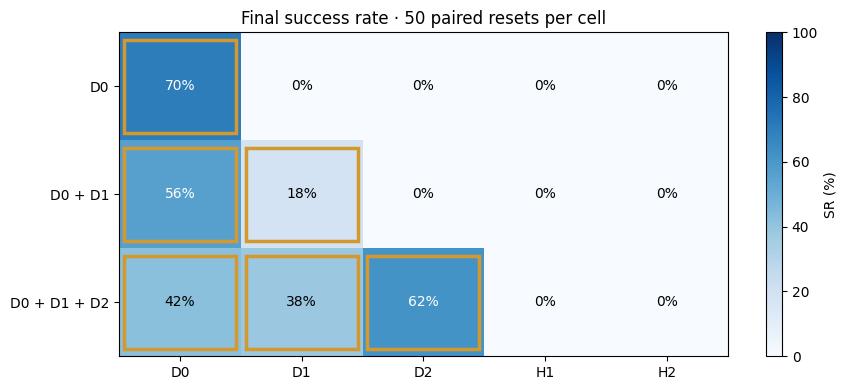

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(9,4))
values = matrix[list(TASKS)].to_numpy()
im = ax.imshow(values, vmin=0, vmax=100, cmap="Blues", aspect="auto")
for i, variant in enumerate(TRAIN_SETS):
    for j, task in enumerate(TASKS):
        ax.text(j, i, f"{values[i,j]:.0f}%", ha="center", va="center", color="white" if values[i,j]>55 else "black")
        if task in TRAIN_SETS[variant]: ax.add_patch(Rectangle((j-.46,i-.43),.92,.86,fill=False,ec="#d5982d",lw=2.5))
ax.set_xticks(range(5), list(TASKS)); ax.set_yticks(range(3), [LABELS[v] for v in TRAIN_SETS])
ax.set_title("Final success rate · 50 paired resets per cell")
fig.colorbar(im, ax=ax, label="SR (%)"); fig.tight_layout(); plt.show()


## 15. Image sensitivity and training trajectory
These diagnostics explain behavior without choosing checkpoints or tuning on held-out outcomes.

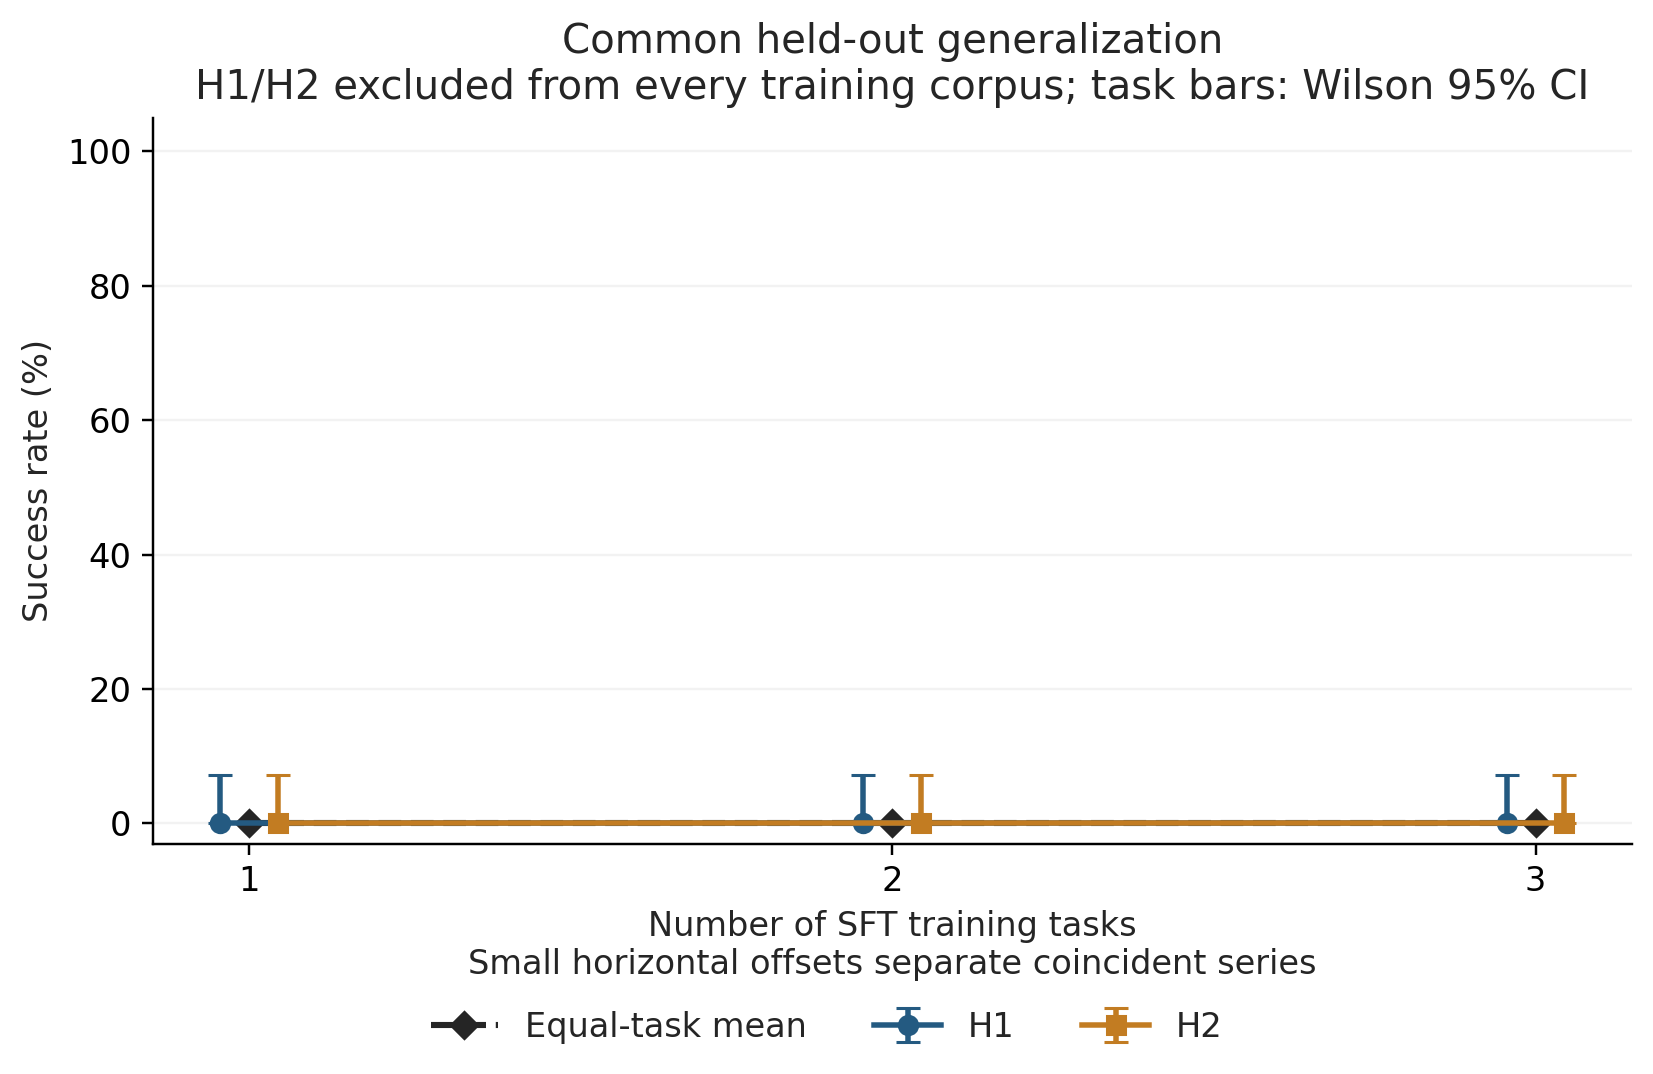

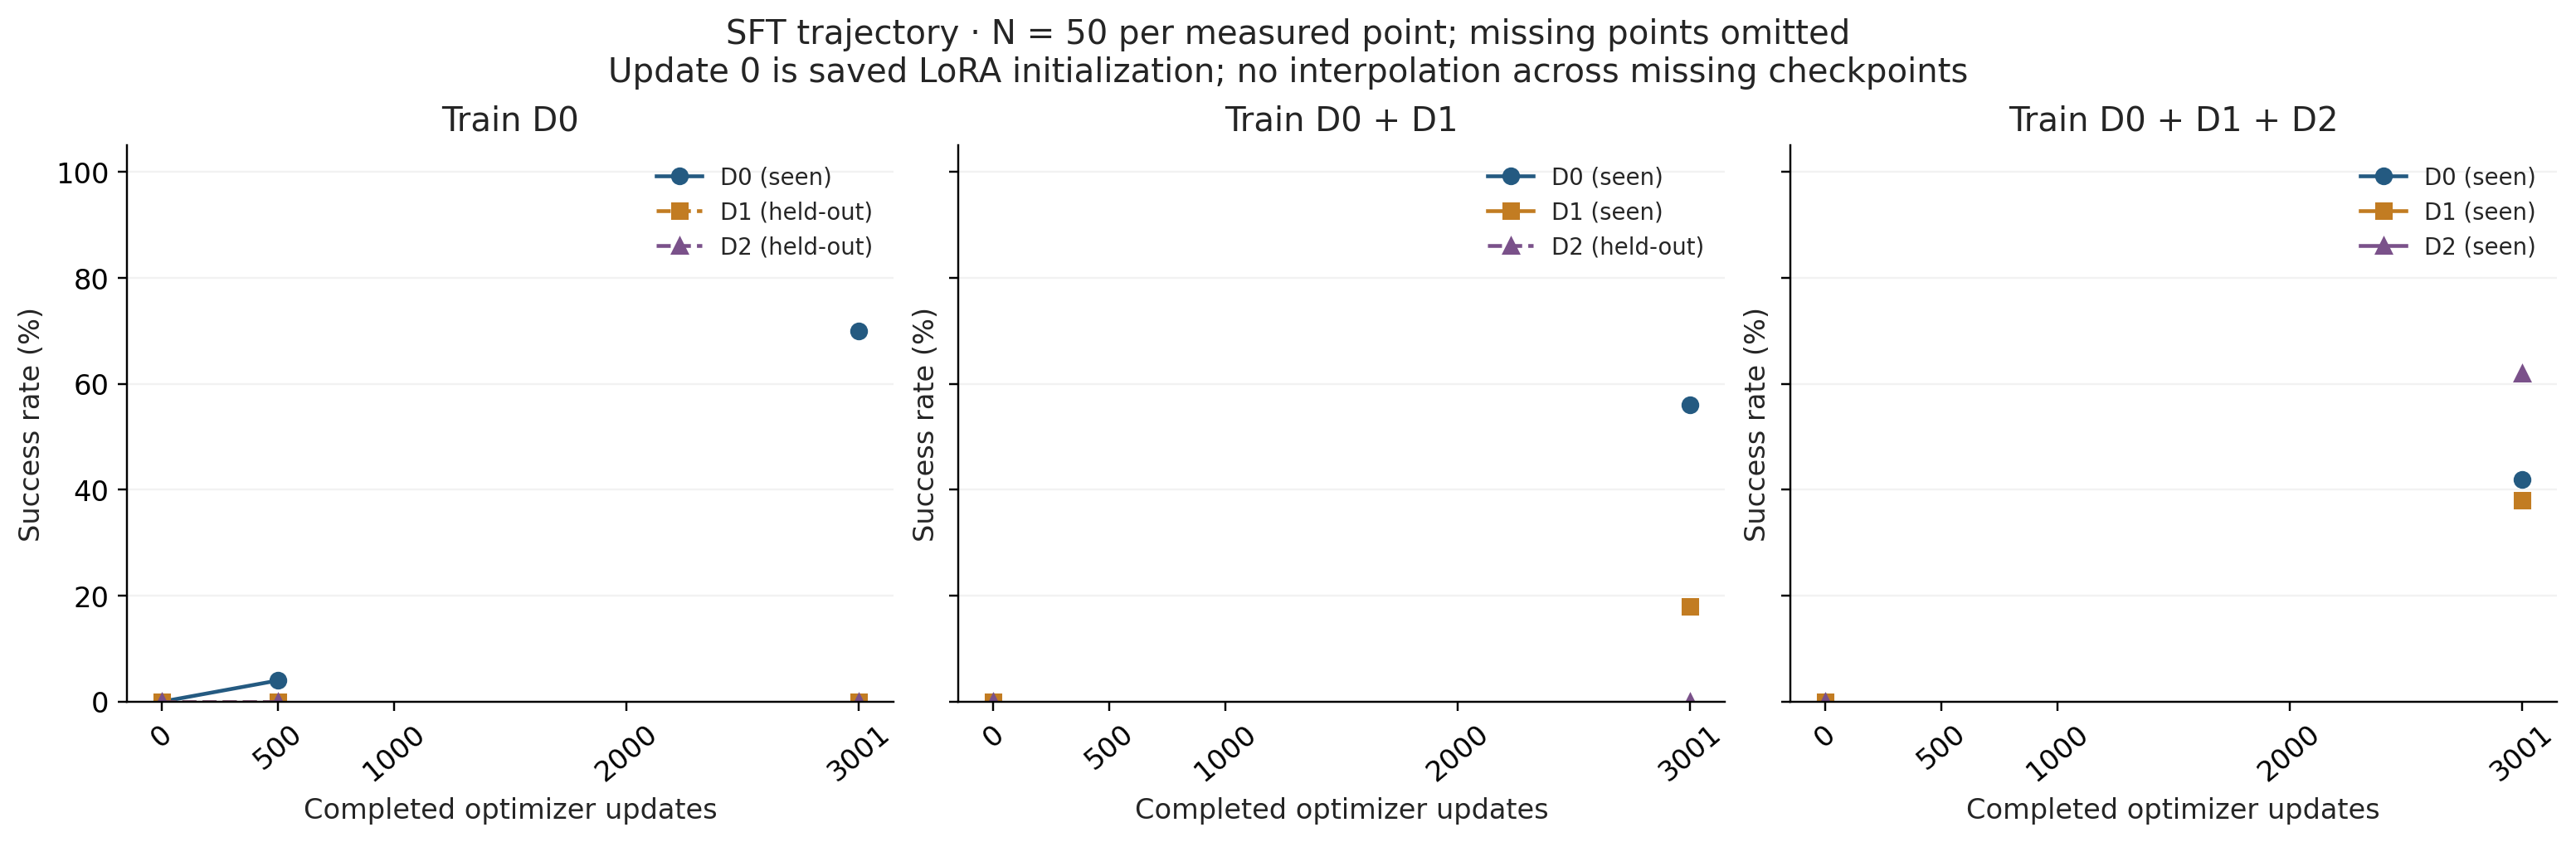

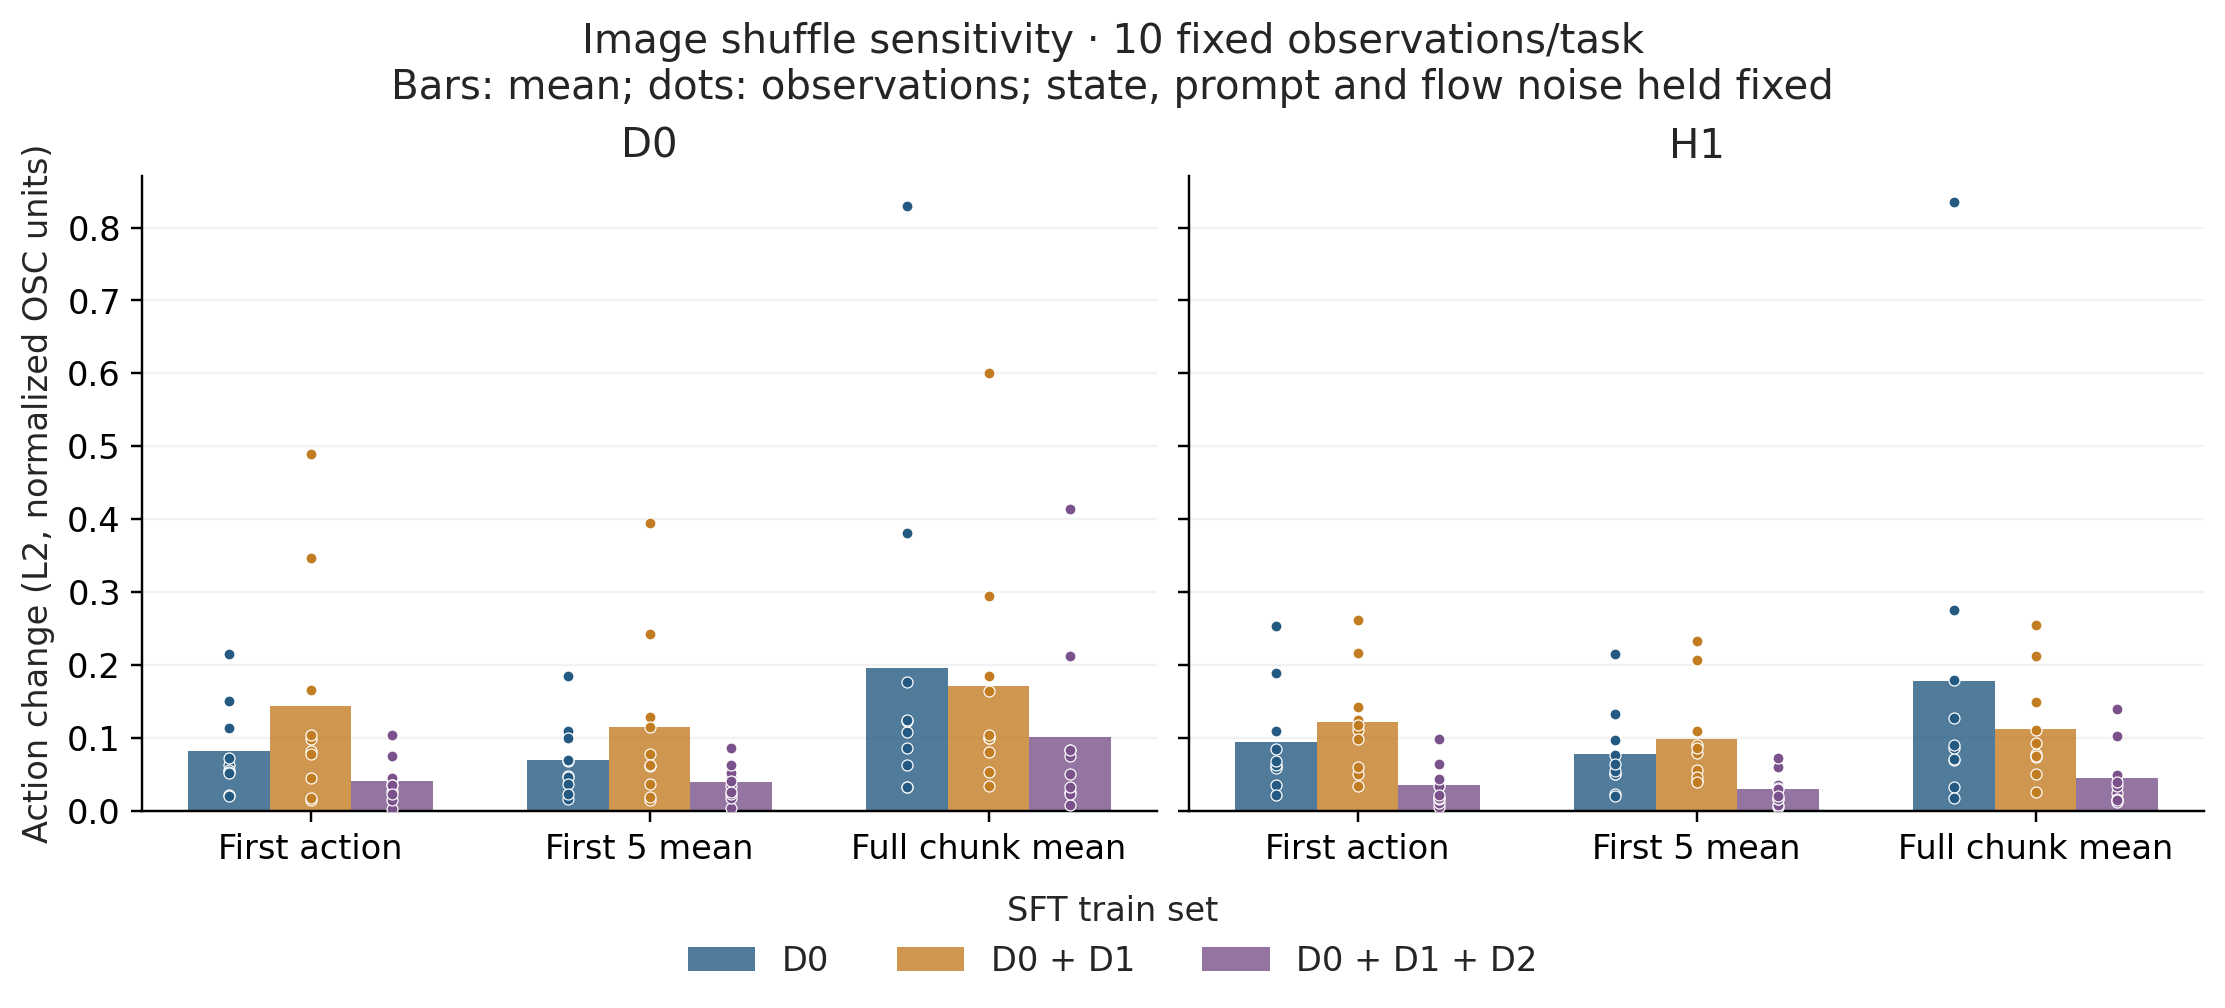

In [15]:
display(Image(filename=str(REPO / "docs/multitask_sft/heldout_generalization.png")))
display(Image(filename=str(REPO / "docs/multitask_sft/sft_trajectory.png")))
display(Image(filename=str(REPO / "docs/multitask_sft/image_sensitivity.png")))


## 16. Change task or checkpoint and rerun
Edit only the configuration cell: for example, set `VARIANT="B"`, point `CHECKPOINT` at its 1,000-update directory, set `TASK="D1"`, `N_EPISODES=5`, `VIDEOS_PER_OUTCOME=1`, and enable `LIVE_EVALUATION`. Then restart the kernel and run all cells. For another compatible π₀ LoRA32 checkpoint, set `VARIANT="external"`, assign `CHECKPOINT`, and enable live evaluation. Its unique normalization asset is discovered automatically, or supply `NORMALIZATION`. Leave `SEEN_TASKS=None` when SFT exposure is unknown, or provide a tuple of registered task IDs; unknown exposure stays explicitly unknown. External evaluations run serially. The command-line equivalent of the registered B example is:

```bash
PYTHONPATH=/workspace/LIBERO:src third_party/openpi/.venv/bin/python scripts/eval_multitask_sft.py \
  --checkpoint /path/to/checkpoint --variant B --task H1 \
  --episodes 50 --seed-start 10000 --videos 2
```

Use the human report for interpretation and the methods appendix for provenance. Never replace the preregistered final table with an exploratory rerun.

In [16]:
if session is not None:
    session.close()
